This notebook follows the 8-step exploratory data analysis framework outlined in 
GeeksforGeeks (2025) and Chugh (n.d.).

##### LinkedIn Job Postings — Exploratory Data Analysis (Module 4)

1. Understand the problem and the data

**Research Question:**

Do job postings with more or narrower skill requirements show a different views-to-applies conversion pattern than postings with fewer/broader requirements?

**Variables:**

- views
- applies
- skill_abr (required per posting)
- company_size
- industry_id
- formatted_experience_level
- location
- original_listed_time

**Data Types:**

- views & applies -> numeric counts
- skill_abr & industry_id -> categorical codes per posting (one-to-many)
- company_size -> categorical

**Limitations:**

- applies is missing from a large share of postings
- skill and industry data are each issing for a small share of postings after merging the tables.

2. Import and go through dataset

In [76]:
# import packages that will be used

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style("whitegrid")

In [77]:
# core files

df = pd.read_csv("../data/postings.csv")
jobSkills = pd.read_csv("../data/jobs/job_skills.csv")
df.shape

(123849, 31)

In [78]:
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
jobSkills.head()

,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN


In [82]:
jobSkills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213768 entries, 0 to 213767
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   job_id     213768 non-null  int64 
 1   skill_abr  213768 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.3+ MB


In [83]:
jobSkills.duplicated().sum()

np.int64(0)

Checking table relationships before merging

`job_skills.csv` is one-to-many relative to job postings: the mean of 1.69 means the average posting has just under 2 sill entries, and the max of 3 means no posting has more than 3.

In [84]:
jobSkills["job_id"].value_counts().describe()

count    126807.000000
mean          1.685774
std           0.675907
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: count, dtype: float64

In [85]:
# aggregate skills to one row per posting before merging 

skillsGrouped = jobSkills.groupby("job_id")["skill_abr"].apply(list).reset_index()

df_merged = df.merge(skillsGrouped, on="job_id", how="left")

df_merged.shape

(123849, 32)

In [86]:
df_merged # the merged data

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,skill_abr
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,"[MRKT, SALE]"
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0,[HCPR]
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,"[MGMT, MNFC]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,[OTHR]
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0,[IT]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,...,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0,"[LGL, BD]"
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,1124131.0,3.0,NaN,...,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,"[ENG, IT]"
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,...,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,NaN,99201.0,53063.0,"[SALE, BD]"
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",2793699.0,4.0,NaN,...,1.713573e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,"[BD, SALE]"


In [87]:
# translate skill codes into readable names
skillsLookup = pd.read_csv("../data/mappings/skills.csv")
skillMap = dict(zip(skillsLookup["skill_abr"], skillsLookup["skill_name"]))

df_merged["skill_names"] = df_merged["skill_abr"].apply(
    lambda codes: [skillMap.get(code, code) for code in codes] if isinstance(codes, list) else codes
)

df_merged[["job_id", "skill_abr", "skill_names"]].head()

,job_id,skill_abr,skill_names
0,921716,"[MRKT, SALE]","[Marketing, Sales]"
1,1829192,[HCPR],[Health Care Provider]
2,10998357,"[MGMT, MNFC]","[Management, Manufacturing]"
3,23221523,[OTHR],[Other]
4,35982263,[IT],[Information Technology]


In [88]:
# bring in company size (1-to-1 on company_id, safe direct merge)
companies = pd.read_csv("../data/companies/companies.csv")
df_merged = df_merged.merge(companies[["company_id", "company_size"]], on="company_id", how="left")

df_merged.shape

(123849, 34)

In [89]:
# bring in job industries (one-to-many, aggregate before merging) with readable names
jobIndustries = pd.read_csv("../data/jobs/job_industries.csv")
industriesLookup = pd.read_csv("../data/mappings/industries.csv")
industryMap = dict(zip(industriesLookup["industry_id"], industriesLookup["industry_name"]))

industriesGrouped = jobIndustries.groupby("job_id")["industry_id"].apply(list).reset_index()
df_merged = df_merged.merge(industriesGrouped, on="job_id", how="left")
df_merged["industry_names"] = df_merged["industry_id"].apply(
    lambda ids: [industryMap.get(i, i) for i in ids] if isinstance(ids, list) else ids
)

df_merged.shape

(123849, 36)

In [90]:
# bring in benefits (one-to-many, aggregate before merging)
benefits = pd.read_csv("../data/jobs/benefits.csv")
benefitsGrouped = benefits.groupby("job_id")["type"].apply(list).reset_index()
df_merged = df_merged.merge(benefitsGrouped, on="job_id", how="left")
df_merged = df_merged.rename(columns={"type": "benefit_types"})

df_merged["has_benefits"] = df_merged["benefit_types"].apply(lambda x: isinstance(x, list))
df_merged.shape

(123849, 38)

In [91]:
# bring in company speciality count
specialities = pd.read_csv("../data/companies/company_specialities.csv")
specialityCounts = specialities.groupby("company_id").size().reset_index(name="speciality_count")

df_merged = df_merged.merge(specialityCounts, on="company_id", how="left")
df_merged["speciality_count"] = df_merged["speciality_count"].fillna(0)

df_merged["speciality_count"].describe()

count    123849.000000
mean          7.555798
std           7.402861
min           0.000000
25%           1.000000
50%           6.000000
75%          12.000000
max          84.000000
Name: speciality_count, dtype: float64

3. Handling missing values

The above merges created some additional missing values, such as postings with no matching entry in the sills or industry tables now show as missing for those fields. 

Separately, the original `postings.csv`already had incomplete data in `views` and `applies`. Since these two fields are central to the conversion-rate metric, rows missing either will be excluded specifically from conversion-rate calculation, but retained in the full dataset for other anaalyses.

In [92]:
df_merged.isnull().sum()

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

In [93]:
usableForConversion = df_merged.dropna(subset=["views", "applies"])
print(f"Postings usable for conversion analysis: {usableForConversion.shape[0]} of {df_merged.shape[0]}")

Postings usable for conversion analysis: 23319 of 123849


In [94]:
# check whether unnamed industry codes affect any postings
missingNameIds = set(industriesLookup[industriesLookup["industry_name"].isnull()]["industry_id"])
affected = df_merged[df_merged["industry_id"].apply(
    lambda ids: any(i in missingNameIds for i in ids) if isinstance(ids, list) else False
)]
print(f"Postings affected by unnamed industry codes: {affected.shape[0]}")

Postings affected by unnamed industry codes: 100


4. Explore data characteristics

In [95]:
df_merged[["views", "applies"]].describe()

,views,applies
count,122160.000000,23320.000000
mean,14.618247,10.591981
std,85.903598,29.047395
min,1.000000,1.000000
25%,3.000000,1.000000
50%,4.000000,3.000000
75%,8.000000,8.000000
max,9975.000000,967.000000


In [96]:
df_merged["location"].value_counts().head(10)

location
United States    8125
New York, NY     2756
Chicago, IL      1834
Houston, TX      1762
Dallas, TX       1383
Atlanta, GA      1363
Boston, MA       1176
Austin, TX       1083
Charlotte, NC    1075
Phoenix, AZ      1059
Name: count, dtype: int64

5. Perform Data Transformation

In [97]:
# derived variables: skill count, conversion rate, a proper datetime field, and a speciality bucket
df_merged["skill_count"] = df_merged["skill_abr"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_merged["conversion_rate"] = df_merged["applies"] / df_merged["views"].replace(0, np.nan)
df_merged["listed_date"] = pd.to_datetime(df_merged["original_listed_time"], unit="ms")

df_merged["speciality_bucket"] = pd.cut(
    df_merged["speciality_count"],
    bins=[-1, 0, 5, 15, float("inf")],
    labels=["None", "1-5", "6-15", "16+"]
)

df_merged[["job_id", "views", "applies", "skill_count", "conversion_rate"]].head()

,job_id,views,applies,skill_count,conversion_rate
0,921716,20.0,2.0,2,0.1
1,1829192,1.0,NaN,1,NaN
2,10998357,8.0,NaN,2,NaN
3,23221523,16.0,NaN,1,NaN
4,35982263,3.0,NaN,1,NaN


6. Visualize data relationships

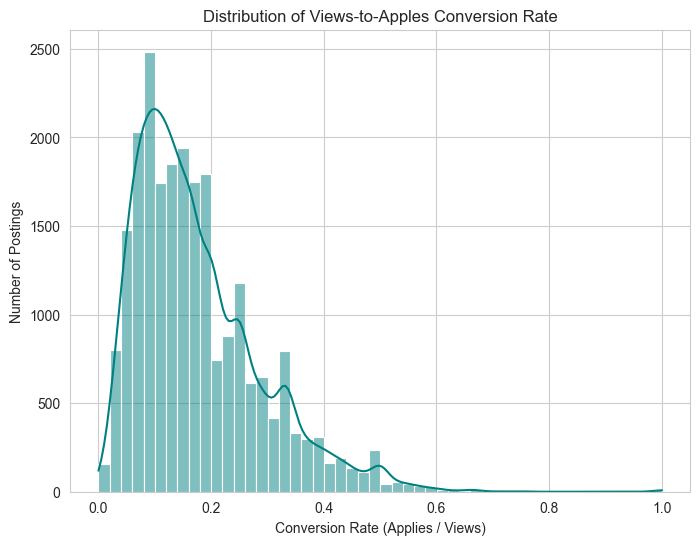

In [98]:
# Viz 1 - Distribution of conversion rate

plt.figure(figsize=(8, 6))

sns.histplot(
    data=df_merged,
    x="conversion_rate",
    bins=50,
    kde=True,
    color="teal"
)

plt.title("Distribution of Views-to-Apples Conversion Rate")

plt.xlabel("Conversion Rate (Applies / Views)")
plt.ylabel("Number of Postings")

plt.show()

The distribution is right-skewed, with most postings clustering between roughly 5% and 25% conversion and a peak near 10%. A long tail extends toward 100% conversion, likely driven by low-view postings where even a single applicant produces an artificially high rate. In practical terms, a typical LinkedIn job posting converts only about 1 in 10 viewers into an applicant, meaning the vast majority of people who see a posting choose not to apply, which is the baseline "leak" this entire project is trying to understand the causes of.

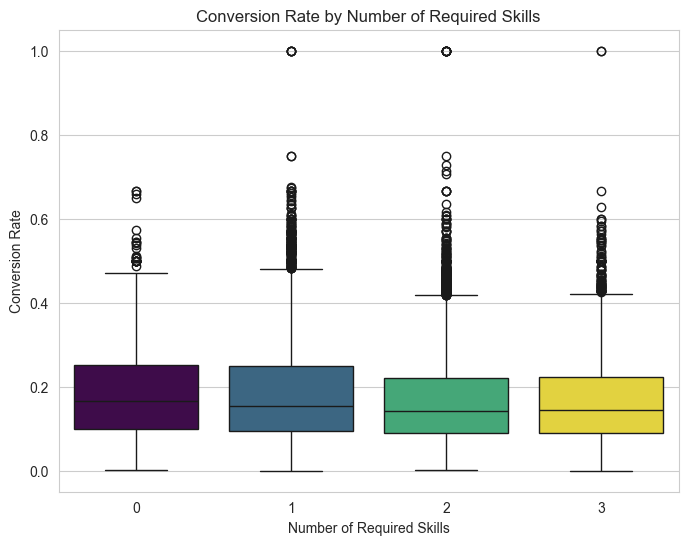

In [99]:
# Viz 2 - Conversion rate by number of required skills (hypothesis)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_merged,
    x="skill_count",
    y="conversion_rate",
    hue="skill_count",
    palette="viridis",
    legend=False
)

plt.title("Conversion Rate by Number of Required Skills")

plt.xlabel("Number of Required Skills")
plt.ylabel("Conversion Rate")

plt.show()

Median conversion rate is nearly identical across 0, 1, 2, and 3 required skills (roughly 0.14-0.17), with heavily overlapping interquartile ranges. This does not show strong support for the hypothesis that more required skills reduce conversion; if this effect exists, it is subtle rather than dramatic, and skill count alone does not appear to be a major driver of conversion in this dataset. With 213,768 total skill entries spread fairly evenly across postings, this suggests job seekers on LinkedIn may not be strongly self-selecting out based on the sheer number of listed requirements, which would mean friction, if it exists, is likely coming from somewhere else in the posting or hiring process rather than skill count itself.

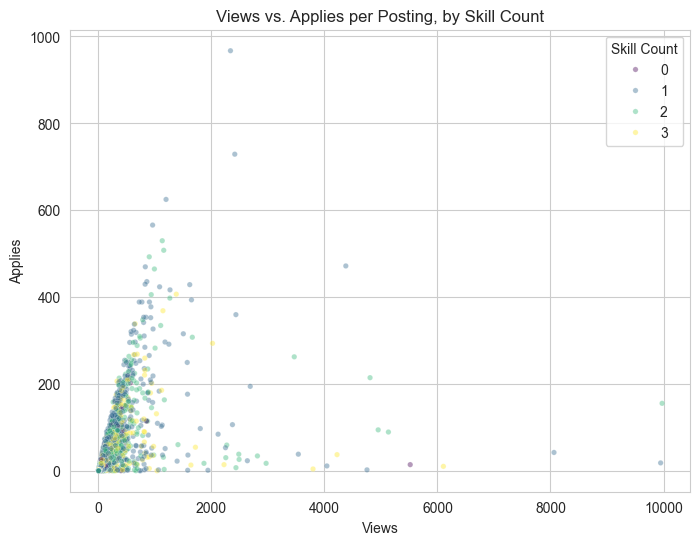

In [100]:
# Viz 3 - Views vs. Apples, colored by skill count
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_merged,
    x="views",
    y="applies",
    hue="skill_count",
    palette="viridis",
    alpha=0.4,
    s=15
)

plt.title("Views vs. Applies per Posting, by Skill Count")

plt.xlabel("Views")
plt.ylabel("Applies")

plt.legend(title="Skill Count")

plt.show()


The relationship between views and applies is strongly positive but with wide variance at higher view counts. Postings with different skill counts (shown by color) are interspersed throughout the scatter rather than forming distinct clusters, reinforcing that skill count alone does not strongly separate posting performance. The wide spread at high view counts also shows that popularity does not guarantee conversion, some heavily viewed postings convert well, others convert poorly, which means views alone are a poor stand-in for how well a posting is actually performing and justifies using the ratio (conversion rate) rather than raw counts throughout this analysis.

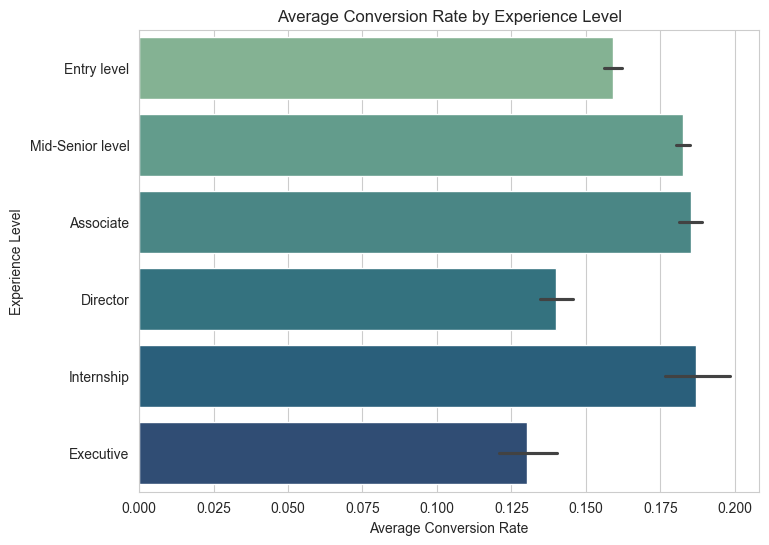

In [101]:
# Viz 4 - Conversion rate by experience
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_merged,
    x="conversion_rate",
    y="formatted_experience_level",
    hue="formatted_experience_level",
    palette="crest",
    errorbar="ci",
    legend=False
)

plt.title("Average Conversion Rate by Experience Level")

plt.xlabel("Average Conversion Rate")
plt.ylabel("Experience Level")

plt.show()

Internship, Associate, and Mid-Senior level postings show the highest average conversion (roughly 0.18-0.19), while Director and Executive roles convert noticeably lower (roughly 0.13-0.14). This suggests that friction or scarcity may be concentrated at the senior end of the hiring funnel rather than distributed evenly across all roles. This pattern is consistent with a genuine talent-scarcity explanation rather than a screening-friction explanation, since senior candidates are a smaller pool by definition, meaning LinkedIn's Talent Solutions division may need different interventions for senior roles (broader sourcing) than for entry-level roles (posting clarity).

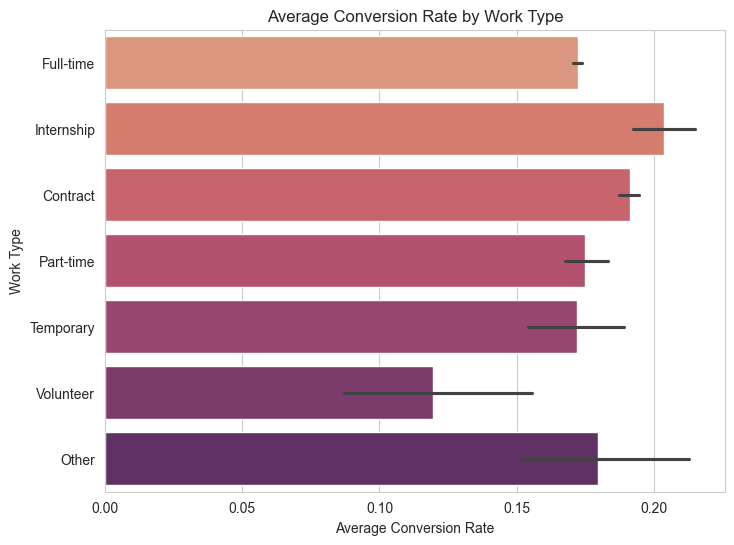

In [102]:
# Viz 5 - Conversion rate by work
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_merged,
    x="conversion_rate",
    y="formatted_work_type",
    hue="formatted_work_type",
    palette="flare",
    errorbar="ci",
    legend=False
)

plt.title("Average Conversion Rate by Work Type")

plt.xlabel("Average Conversion Rate")
plt.ylabel("Work Type")

plt.show()

Internship and Contract postings convert highest (roughly 0.19-0.20), while Volunteer postings convert lowest (roughly 0.12). The wide confidence interval for Volunteer postings suggests a small sample size, so this result should be treated cautiously rather than as a reliable pattern. Full-time postings, which make up the overwhelming majority of the dataset, sit close to the overall average (~0.17), meaning work type is not producing dramatic swings for the job type employers care about most, which somewhat narrows where meaningful friction is likely to be found.

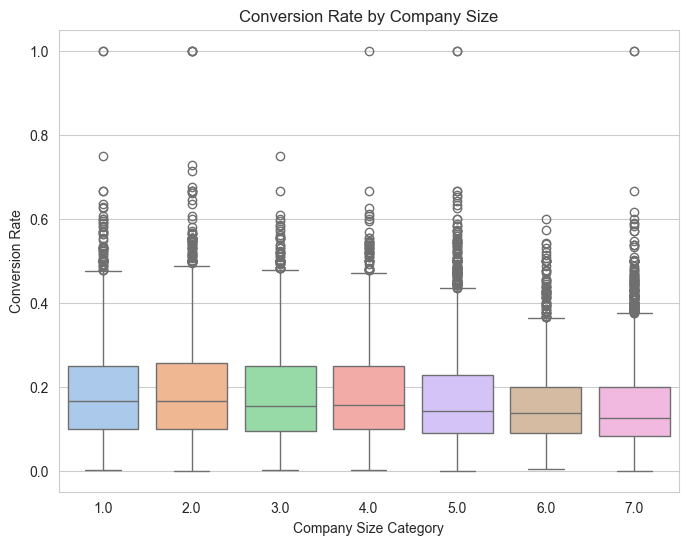

In [103]:
# Viz 6 - Conversion rate by company size
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_merged,
    x="company_size",
    y="conversion_rate",
    hue="company_size",
    palette="pastel",
    legend=False
)

plt.title("Conversion Rate by Company Size")

plt.xlabel("Company Size Category")
plt.ylabel("Conversion Rate")

plt.show()

Conversion rate trends slightly downward as company size category increases, from roughly 0.17 for the smallest size category to roughly 0.13-0.14 for the largest. This suggests postings from larger employers may see modestly lower applicant conversion, though the effect is not large. Given that company size data comes from a separate, largely complete table (missing in only about 5% of merged records), this is a reasonably trustworthy finding, and it hints that candidates may perceive smaller companies as more approachable or their postings as more differentiated, worth a follow-up question in Module 5 or 6 rather than a firm conclusion here.

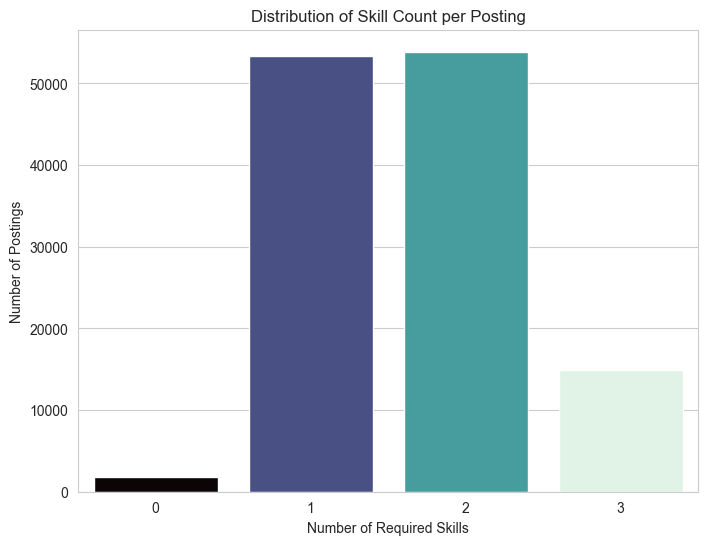

In [104]:
# Viz 7 - Distribution of Skill count
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df_merged,
    x="skill_count",
    hue="skill_count",
    palette="mako",
    legend=False
)

plt.title("Distribution of Skill Count per Posting")

plt.xlabel("Number of Required Skills")
plt.ylabel("Number of Postings")

plt.show()

The large majority of postings require either 1 or 2 skills (roughly 53,000-54,000 postings each), while very few require 0 skills (about 2,000) or 3 skills (about 15,000). Most of the dataset's variation in skill requirements sits within this narrow 1-2 skill range. This narrow range is itself an important finding for the project: since the data offers little contrast between "very few requirements" and "many requirements," the dataset may not actually contain enough variation in skill specificity to strongly test the original hypothesis, which is a real limitation worth naming directly in the Data Quality Report.

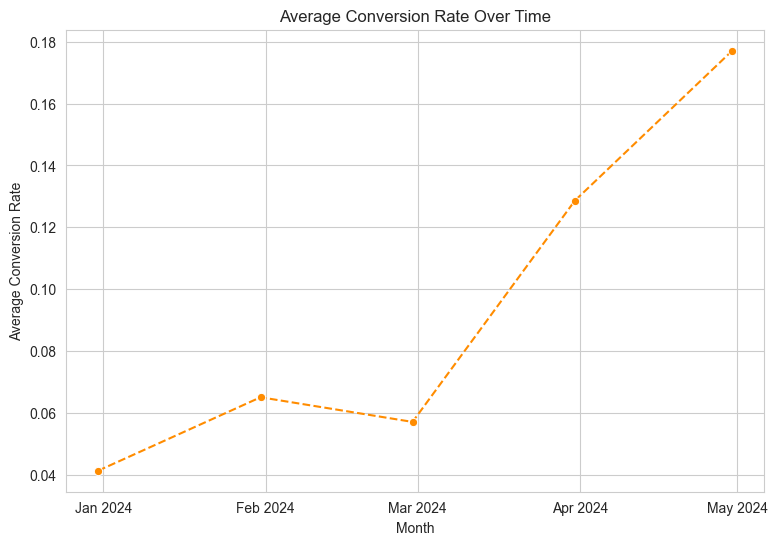

In [105]:
# Viz 8 - Conversion rate over time
import matplotlib.dates as mdates

monthlyConversion = df_merged.set_index("listed_date").resample("ME")["conversion_rate"].mean().reset_index()

plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=monthlyConversion,
    x="listed_date",
    y="conversion_rate",
    marker="o",
    linestyle="--",
    color="darkorange"
)

# format x-axis to show clean "Jan 2024" style labels
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=0)
plt.title("Average Conversion Rate Over Time")

plt.xlabel("Month")
plt.ylabel("Average Conversion Rate")

plt.grid(True)

plt.show()

Average conversion rate rises steadily from January through May 2024, with a sharp increase in the final two months. This trend should be interpreted cautiously: Visual 11 shows an extreme spike in posting volume during this same window, which is likely a scraping artifact rather than genuine market change, so this apparent trend may not reflect a real shift in conversion behavior. Because the underlying sample size per month is not constant, any month-over-month comparison here is comparing a handful of early postings against tens of thousands of later ones, meaning this chart cannot currently be used to make a claim about seasonal or time-based hiring patterns.

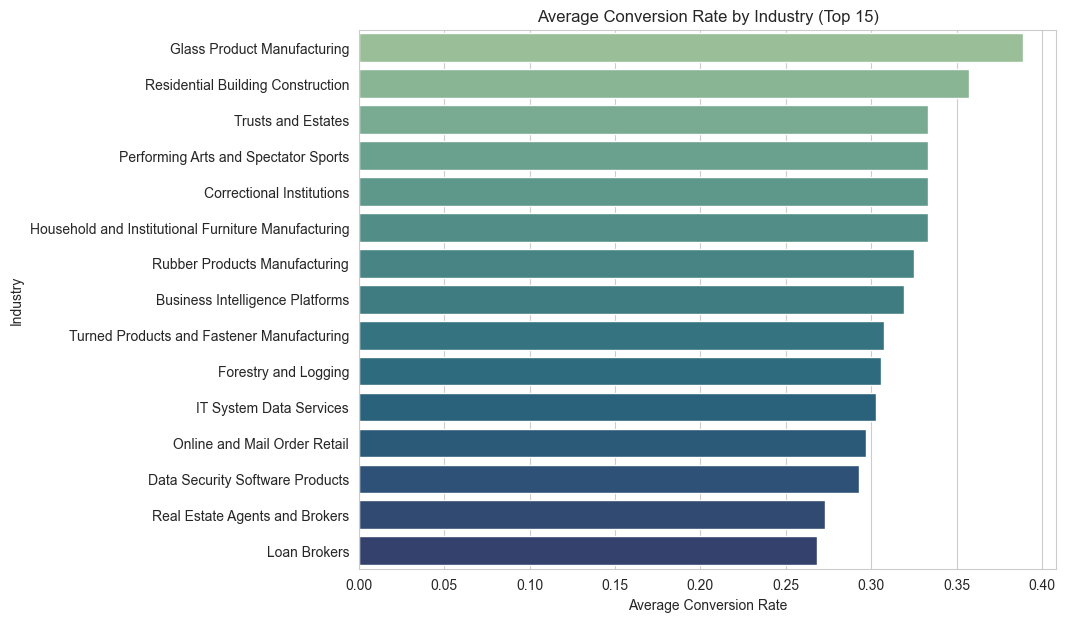

In [106]:
# Viz 9 - Conversion Rate by industry (top 15)
industryExploded = df_merged.explode("industry_names").reset_index(drop=True)
topIndustries = industryExploded.groupby("industry_names")["conversion_rate"].mean().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(9, 7))
sns.barplot(
    data=topIndustries,
    x="conversion_rate",
    y="industry_names",
    hue="industry_names",
    palette="crest",
    legend=False
)

plt.title("Average Conversion Rate by Industry (Top 15)")

plt.xlabel("Average Conversion Rate")
plt.ylabel("Industry")

plt.show()

Glass Product Manufacturing and Residential Building Construction show the highest average conversion rates (roughly 0.36-0.39). These are niche industries likely represented by a small number of postings, so these results should be treated as exploratory rather than statistically robust without confirming the sample size behind each industry. Since 164,808 industry-tagged rows are spread across 422 possible industry categories, many individual industries likely have only a handful of postings each, meaning this ranking is probably more reflective of small-sample noise than a real, generalizable industry effect on conversion.

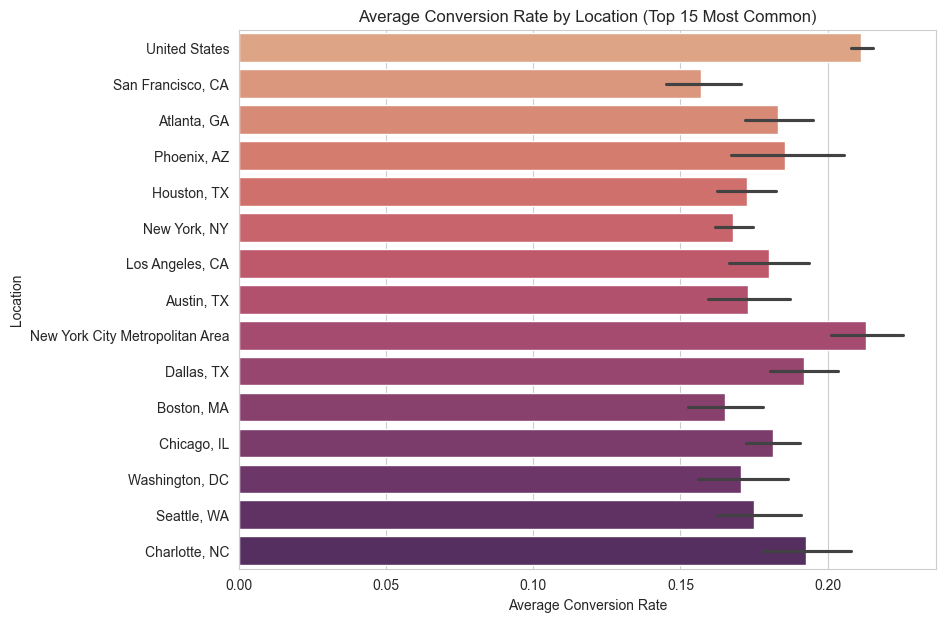

In [107]:
# Viz 10 - Conversion rate by locatoin (top 15 most common)
topLocations = df_merged["location"].value_counts().head(15).index
locationSubset = df_merged[df_merged["location"].isin(topLocations)]

plt.figure(figsize=(9, 7))
sns.barplot(
    data=locationSubset,
    x="conversion_rate",
    y="location",
    hue="location",
    palette="flare",
    errorbar="ci",
    legend=False
)

plt.title("Average Conversion Rate by Location (Top 15 Most Common)")

plt.xlabel("Average Conversion Rate")
plt.ylabel("Location")

plt.show()

Conversion rates are fairly consistent across the most common posting locations (roughly 0.15-0.21). "New York City Metropolitan Area" and "United States," likely broader remote or national postings, show the highest rates, suggesting location alone is not a strong differentiator of conversion. The fact that "United States" alone accounts for over 8,000 postings, the single largest location group, suggests a meaningful share of employers post without specifying a precise city, which is itself a posting-design choice that could be worth investigating as its own variable in a future phase.

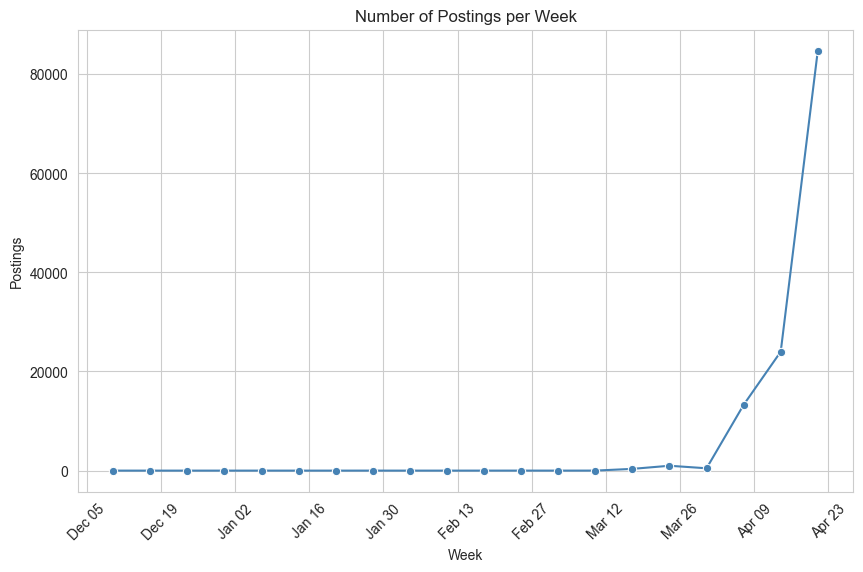

In [108]:
# Viz 11 - Posting volume over time
weeklyVolume = df_merged.set_index("listed_date").resample("W")["job_id"].count().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=weeklyVolume,
    x="listed_date",
    y="job_id",
    marker="o",
    color="steelblue"
)

# show a tick every 2 weeks, clean date format
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)

plt.title("Number of Postings per Week")

plt.xlabel("Week")
plt.ylabel("Postings")

plt.grid(True)

plt.show()

Posting volume is near zero for most of the observed period, then spikes dramatically to roughly 85,000 postings in the final week. This pattern strongly suggests the scraping process captured a large batch of postings at once near the end of data collection, rather than reflecting genuine week-over-week growth. This is an important data quality limitation for interpreting any time-based pattern in this dataset, including the trend shown in Visual 8. Practically, this means the dataset behaves more like a single large snapshot than a true longitudinal record, which matches the constraint already flagged in the Selection Criteria section regarding the dataset's scraping window.

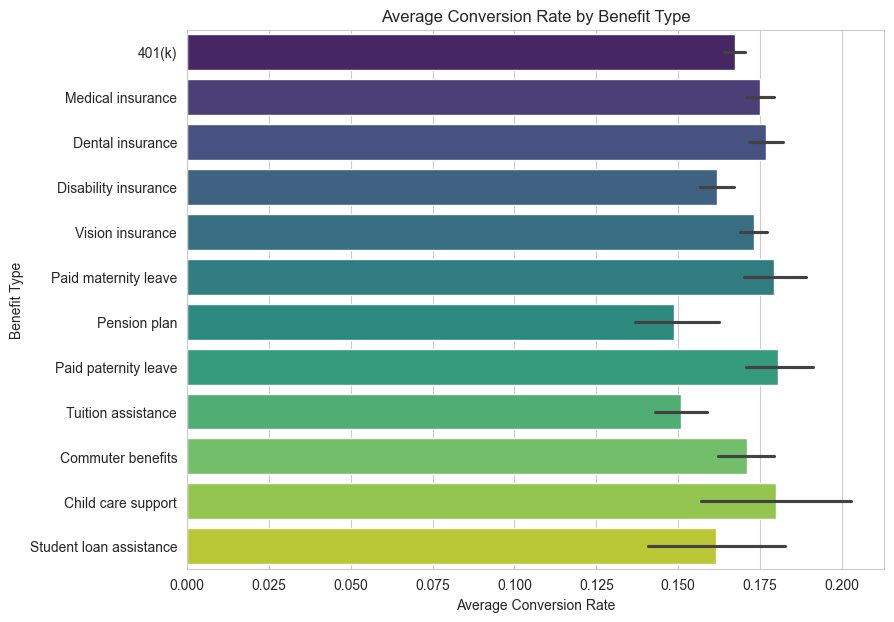

In [109]:
# Viz 12 - Conversion rate by benefit type
benefitsExploded = df_merged.explode("benefit_types").reset_index(drop=True)

plt.figure(figsize=(9, 7))
sns.barplot(
    data=benefitsExploded,
    x="conversion_rate",
    y="benefit_types",
    hue="benefit_types",
    palette="viridis",
    errorbar="ci",
    legend=False
)

plt.title("Average Conversion Rate by Benefit Type")
plt.xlabel("Average Conversion Rate")
plt.ylabel("Benefit Type")
plt.show()

Conversion rates are fairly similar across benefit types (roughly 0.15-0.18), with paid parental leave and child care support trending slightly higher and pension plans and tuition assistance trending slightly lower. The differences are modest and do not suggest benefit type is a major driver of conversion. With benefit data available for only about 46,000 of 123,849 postings (roughly 37%), this comparison is also limited to postings that chose to disclose benefits at all, meaning the finding applies specifically to that subset rather than the full posting population.

In [ ]:
# this code must be ran so the error from below wont happen. for vis 12.

salaries = pd.read_csv("../data/jobs/salaries.csv")
postingsWithSalary = set(salaries["job_id"])

df_merged["has_salary_data"] = df_merged["job_id"].isin(postingsWithSalary)
df_merged["has_salary_data"].value_counts()

has_salary_data
False    87776
True     36073
Name: count, dtype: int64

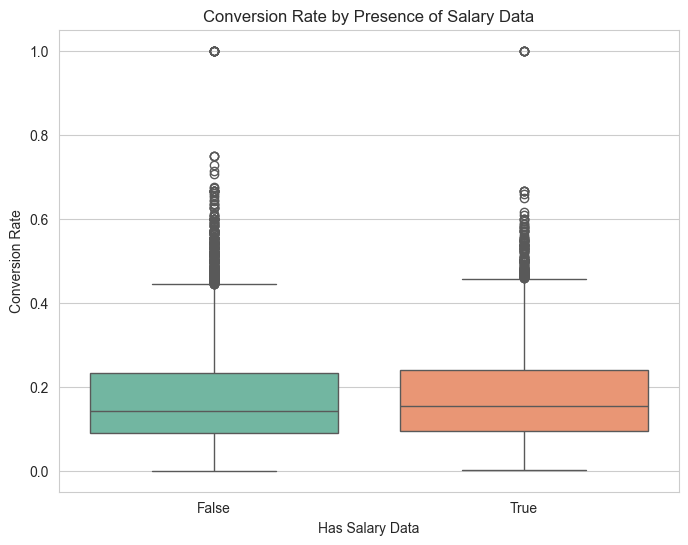

In [114]:
# Viz 13 - Conversion rate by salary data presence
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_merged,
    x="has_salary_data",
    y="conversion_rate",
    hue="has_salary_data",
    palette="Set2",
    legend=False
)

plt.title("Conversion Rate by Presence of Salary Data")

plt.xlabel("Has Salary Data")
plt.ylabel("Conversion Rate")

plt.show()

Postings with and without associated salary data show nearly identical conversion rate distributions (median around 0.15 for both), suggesting salary transparency alone does not meaningfully affect applicant conversion in this dataset. This is a notable finding given ongoing industry discussion about pay transparency laws, since it implies that simply disclosing a salary range, without other changes, is not enough on its own to noticeably change how many viewers convert to applicants for a typical posting.

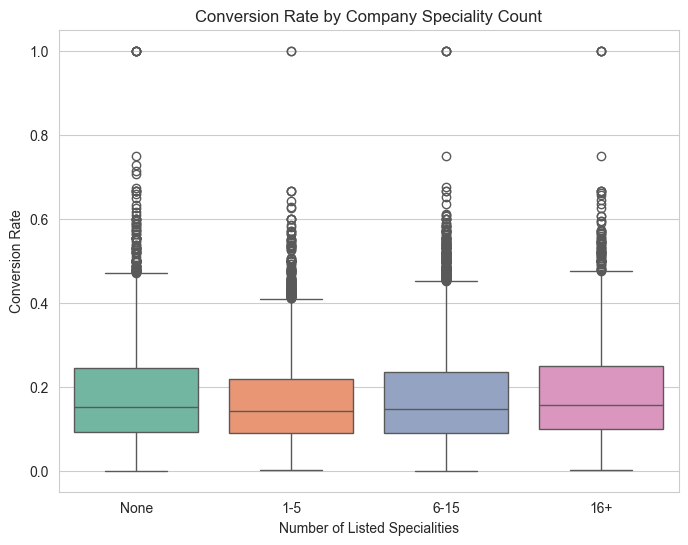

In [115]:
# Viz 14 - Conversion rate by company speciality count
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_merged,
    x="speciality_bucket",
    y="conversion_rate",
    hue="speciality_bucket",
    palette="Set2",
    legend=False
)

plt.title("Conversion Rate by Company Speciality Count")

plt.xlabel("Number of Listed Specialities")
plt.ylabel("Conversion Rate")

plt.show()

Conversion rate is very similar across all speciality-count buckets (roughly 0.14-0.16 median), showing no clear relationship between how many specialities a company lists and how its postings convert. This suggests that how a company describes its own business scope on LinkedIn has little bearing on whether individual job seekers convert on a specific posting, which makes sense given that speciality count is a company-level attribute rather than something a candidate is likely to see or weigh heavily when deciding whether to apply to a specific role.

7. Handling outliers

In [116]:
implausible = (df_merged["applies"] > df_merged["views"]).sum()
print(f"Postings where applies > views (implausible): {implausible}")

naViews = (df_merged["views"] == 0).sum()
print(f"Postings with 0 views: {naViews}")

Postings where applies > views (implausible): 0
Postings with 0 views: 0


In [117]:
Q1 = df_merged["conversion_rate"].quantile(0.25)
Q3 = df_merged["conversion_rate"].quantile(0.75)

IQR = Q3 - Q1

outliers = df_merged[(df_merged["conversion_rate"] < Q1 - 1.5*IQR) | (df_merged["conversion_rate"] > Q3 + 1.5*IQR)]

print(f"Conversion Rate outliers (IQR method): {outliers.shape[0]}")

Conversion Rate outliers (IQR method): 652


Title and Description — qualitative exploration (not charted)

These are free-text fields without a natural numeric chart form. A quick word-frequency check is used instead, mainly as a sanity check against the structured skill coding.

In [118]:
df_merged["title"].str.lower().str.split().explode().value_counts().head(20)

title
-                 31473
manager           15645
engineer           9135
sales              8103
senior             7932
assistant          6467
specialist         6220
associate          6027
technician         4989
nurse              4812
analyst            4409
and                3874
service            3611
&                  3525
time               3249
project            3229
lead               2958
director           2928
registered         2883
representative     2848
Name: count, dtype: int64

8. Communicate findings and insights

**Summary of key findings**

Across the fourteen visuals explored above, the original hypothesis, that more specific or numerous skill requirements directly suppress applicant conversion, is not strongly supported by this dataset (Visuals 2, 3). Conversion rate remained largely flat across skill count, and the dataset's own distribution of skill counts (Visual 7) offers limited contrast to test this relationship rigorously, since the large majority of postings require just 1 or 2 skills.

Instead, the strongest and most consistent pattern in the data is by **experience level**: senior roles (Director, Executive) show meaningfully lower conversion than entry-level, associate, and internship postings (Visual 4). A secondary, weaker pattern appears by **company size**, with larger employers showing modestly lower conversion than smaller ones (Visual 6). Several other factors tested, salary data presence, benefit type, listed company specialities, showed little to no relationship with conversion (Visuals 12, 13, 14), which helps rule out those as major drivers.

A significant data quality limitation was also identified: posting volume is heavily concentrated in a single final week of the dataset's collection window (Visual 11), which likely reflects a scraping artifact rather than genuine market activity. Any apparent time-based trend (Visual 8) should therefore be treated with caution rather than interpreted as a real seasonal or growth pattern.

**Revised hypothesis**

Rather than skill requirement count alone, applicant conversion is more likely associated with **role seniority**, and to a lesser extent **company size**, than with how many skills a posting lists. Senior roles may see lower conversion due to genuine talent scarcity (a smaller qualified candidate pool) rather than self-inflicted posting-design friction.

**Identified actions**

1. Shift the analytical focus from skill count as the primary predictor to experience level as the primary predictor of conversion.
2. Treat company size as a secondary, exploratory factor worth continued investigation rather than a confirmed driver.
3. Flag the posting-volume data quality issue explicitly in the Data Quality Report, and avoid drawing time-based conclusions from this dataset without further validation.
4. Retain skill count as a secondary variable, since its lack of a strong effect is itself a meaningful, reportable finding, it suggests that if screening friction exists, it likely stems from something other than the sheer number of listed requirements.

**Data mining goal**

Translating this revised hypothesis into technical terms: this phase's data mining goal is to **model conversion rate as a function of posting-level attributes, primarily experience level, and secondarily company size, work type, and skill count**, using the available posting-level dataset. Given that the outcome variable (conversion rate) is continuous, this is best framed as a **regression problem**, with experience level and company size explored as the leading candidate predictors, rather than skill count alone as originally proposed in Module 2. This posting-level analysis establishes a measurable, evidence-based foundation for the broader funnel-friction diagnosis described in Business Objectives, while being explicit that applicant-level and ATS-outcome data, not available in this dataset, would be required to test the algorithmic-screening dimension of the original business problem directly.

### References

This notebook follows the 8-step exploratory data analysis framework outlined in GeeksforGeeks (2025), incorporating best practices for missing-data analysis and feature assessment described by Santos (2023).

- GeeksforGeeks. (2025, July 23). *Steps for mastering exploratory data analysis | EDA steps.* https://www.geeksforgeeks.org/data-analysis/steps-for-mastering-exploratory-data-analysis-eda-steps/
- Santos, M. (2023, May 30). *A data scientist's essential guide to exploratory data analysis.* Medium. https://medium.com/data-science/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6